# TextGraphicalizer: first WordNet ontology pass

Run the Laya-backed `TextGraphicalizer` on made-up paragraphs using the checked-in high-level WordNet ontology. The estimator owns the parameterized graph display function, so rendering can be reused outside this notebook.

> The first model load downloads the pinned Laya checkpoint into the Hugging Face cache.

## One-time setup

Use the existing `py312` kernel backed by the project venv. From the repository root, run these commands once in a terminal:

```bash
source ~/.venvs/py312/bin/activate
python -m pip install -e ".[notebook]"
python -m ipykernel install --user --name py312 --display-name "py312"
```

In [1]:
from pathlib import Path
import sys

assert sys.version_info[:2] == (3, 12), (
    f"Select the 'py312' kernel; current interpreter is {sys.version}"
)
print(f"Using Python: {sys.executable}")

import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "ontology.yaml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from textgraphicalizer import TextGraphicalizer

plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 15, "font.size": 10})
ontology_path = ROOT / "ontology.yaml"
ontology_path

Using Python: /Users/f.costa/.venvs/py312/bin/python


PosixPath('/Users/f.costa/Code/TextGraphicalizer/ontology.yaml')

In [2]:
extractor = TextGraphicalizer(
    ontology=ontology_path,
    node_threshold=0.45,
    edge_threshold=0.50,
    connected=False,
    max_node_degree=4,
    device="auto",
).fit()

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

## Made-up paragraphs

In [3]:
paragraphs = [
    ("Storm response", "After a heavy storm, the river flooded the village and forced the emergency organization to move residents to a nearby shelter."),
    ("Drought and harvest", "The research team published a report explaining that repeated drought reduced the harvest and changed the condition of the soil."),
    ("Robot workshop", "A university launched a program that taught students how to build a small robot from metal parts and use it in the laboratory."),
]

graphs = []
for title, paragraph in paragraphs:
    graph = extractor.transform(paragraph)
    graphs.append((title, paragraph, graph))
    print(f"{title}: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")

Storm response: 3 nodes, 0 edges
Drought and harvest: 2 nodes, 0 edges
Robot workshop: 6 nodes, 12 edges


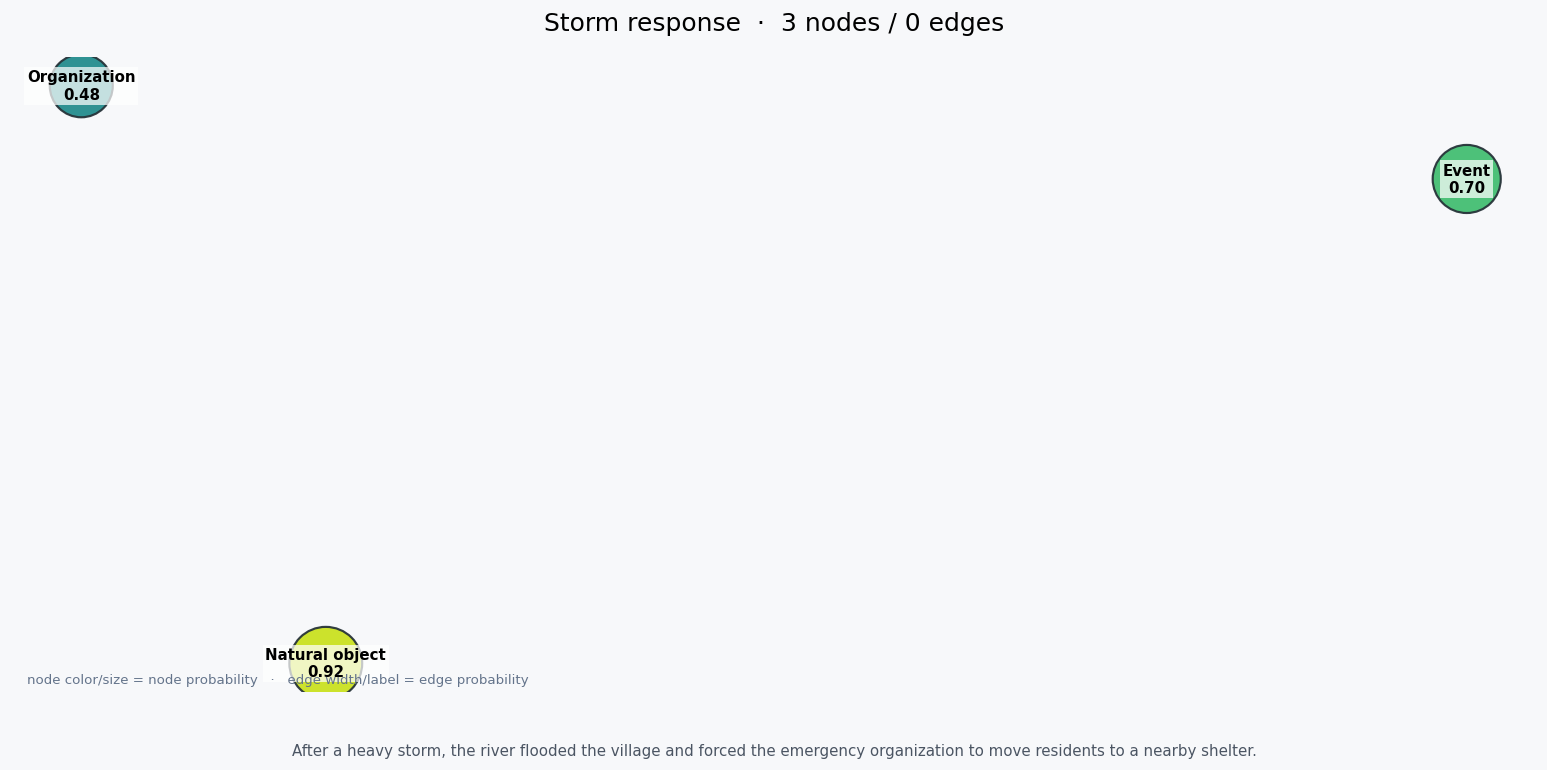

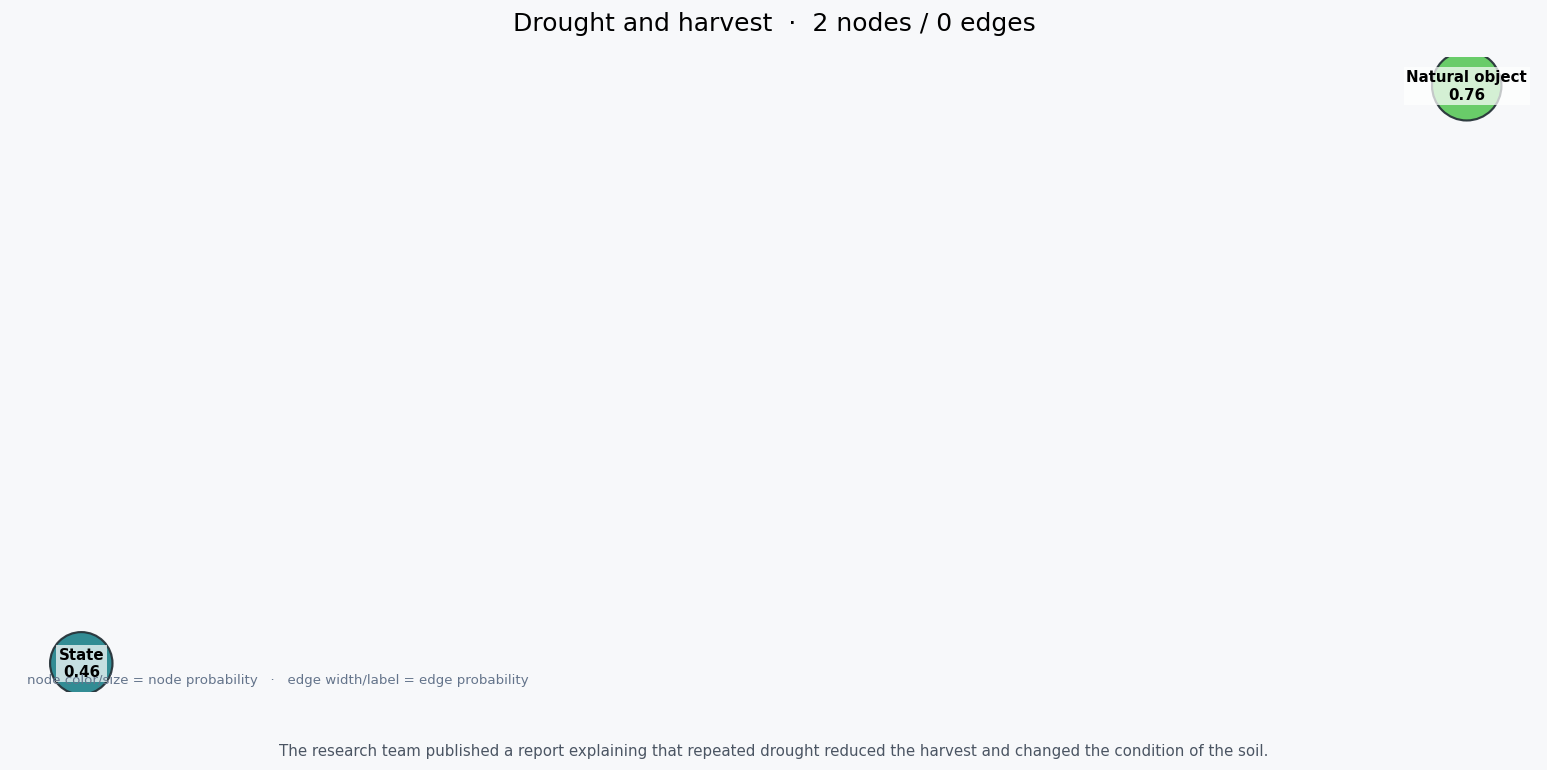

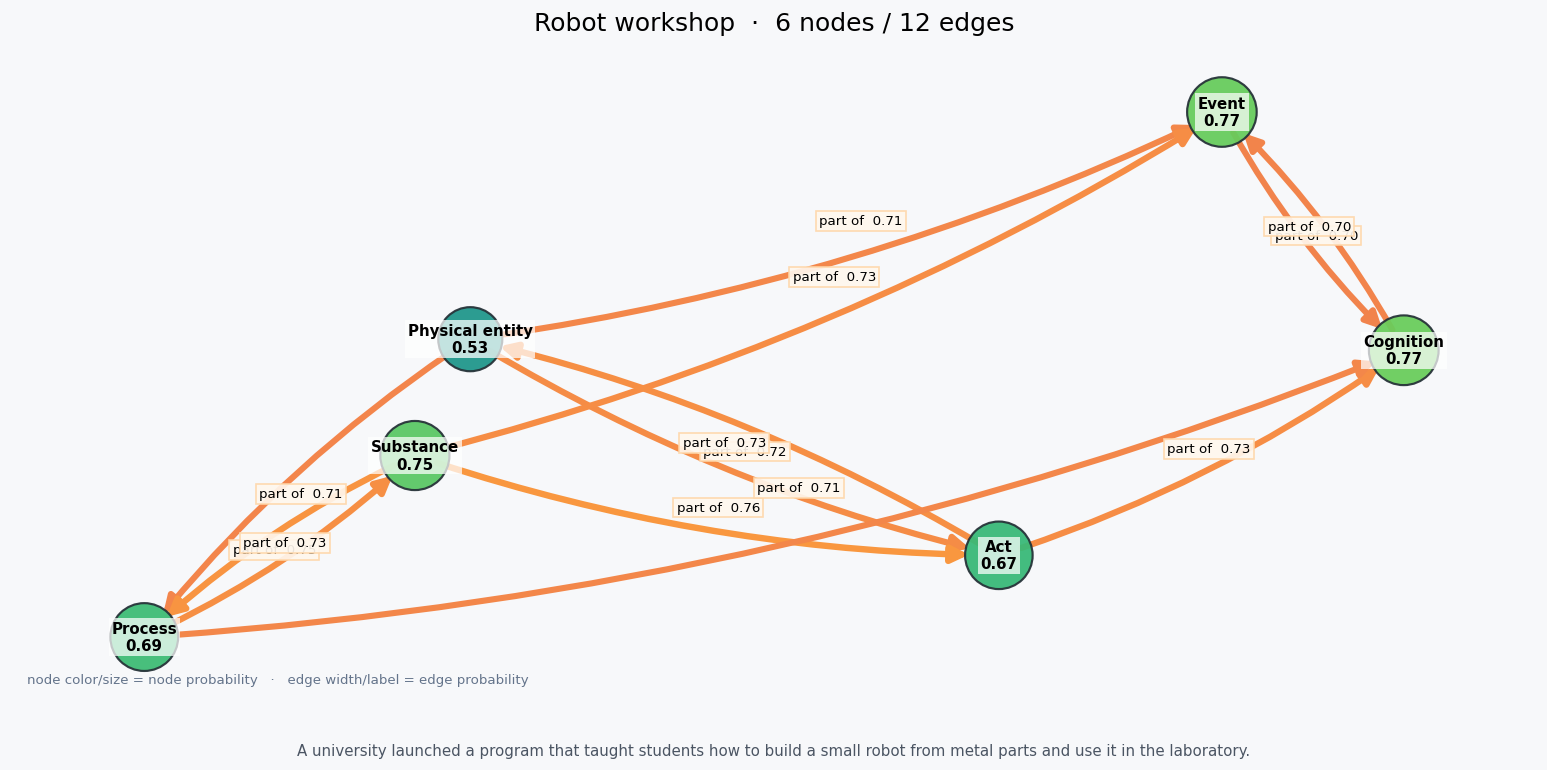

In [4]:
for title, paragraph, graph in graphs:
    extractor.display(
        graph,
        title=title,
        paragraph=paragraph,
        layout="spring",
        seed=17,
        node_size=1200,
        node_color="white",
        edge_color="black",
        show_probabilities=False,
        scale_edge_width_by_probability=False,
        show=True,
    )

## Inspect one graph as ordinary NetworkX data

In [5]:
title, paragraph, graph = graphs[0]
print("Nodes:")
display(list(graph.nodes(data=True)))
print("Edges:")
display(list(graph.edges(data=True)))
print("Graph metadata:")
display(graph.graph)

Nodes:


[('organization',
  {'label': 'Organization', 'probability': 0.4813, 'confidence': 0.5187}),
 ('natural_object',
  {'label': 'Natural object', 'probability': 0.9181, 'confidence': 0.9181}),
 ('event', {'label': 'Event', 'probability': 0.6986, 'confidence': 0.6986})]

Edges:


[]

Graph metadata:


{'ontology_version': 1,
 'model_id': 'convaiinnovations/laya',
 'model_revision': '7c76b622dfc5cac71b2dc1c29873efe2ce509a05',
 'node_threshold': 0.45,
 'edge_threshold': 0.5,
 'connected': False,
 'max_node_degree': 4,
 'solver': 'scipy.optimize.milp',
 'input_truncated': False}